# 03 — ADME Experiments: Learning Curves & Noise Injection

**Goal**: Quantify how dataset size and label noise affect ML model performance for ADME endpoints.
**Phases**: 4 (learning curves), 5 (noise injection), 5b (validation quality), 6 (2D grid).
**Upstream**: Baseline models and tuning pipeline from `01_adme_eda_baseline.ipynb`.

In [16]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.features import rdkit_2d_features
from src.cleaning import filter_endpoint
from src.models import get_baseline_models, evaluate_model
from src.tuning import tune_lightgbm, tune_rf
from src.noise import add_gaussian_noise, add_systematic_bias, add_gross_errors

SEED = 42
DATA_PATH = '../data/raw/ADME_public_set_3521.csv'

# ── Run flags ──
RUN_LEARNING_CURVES = True
RUN_NOISE_INJECTION = True
RUN_MPNN2_EXPERIMENTS = True  # expensive — set True to include MPNN2

# ── MPNN2 seed budget ──
MPNN2_N_SEEDS = 1   # 1 = once per condition, fast (~84 min total for Ph4+5)
                     # set to N_SEEDS for full overnight run with variance estimates

# ── Experiment config ──
FRACTIONS = [0.05, 0.10, 0.25, 0.50, 0.75, 1.0]
N_SEEDS = 10
TUNE_N_ITER = 50       # match notebook 01
TUNE_VAL_FRAC = 0.2    # val fraction for tune_* — matches notebook 01

# ── Noise levels ──
GAUSSIAN_SIGMAS = [0.0, 0.1, 0.3, 0.5, 1.0]      # fraction of endpoint std
BIAS_FRACS = [0.0, 0.1, 0.3, 0.5, 1.0]             # fraction of endpoint std
GROSS_ERROR_FRACS = [0.0, 0.01, 0.05, 0.10, 0.20]  # fraction of labels replaced

# ── Endpoints (modelling subset — PPB excluded) ──
MODEL_ENDPOINTS = [
    'LOG HLM_CLint (mL/min/kg)',
    'LOG MDR1-MDCK ER (B-A/A-B)',
    'LOG SOLUBILITY PH 6.8 (ug/mL)',
    'LOG RLM_CLint (mL/min/kg)',
]
EP_SHORT = ['HLM', 'MDR1', 'SOL', 'RLM']
EP_SHORT_MAP = dict(zip(MODEL_ENDPOINTS, EP_SHORT))

print('Imports OK')

Imports OK


**Run flags**: Set `RUN_LEARNING_CURVES` / `RUN_NOISE_INJECTION` to `False` to skip recomputation — the skip branches load existing results from `data/processed/` automatically. This means MPNN2 (or any future model) can be added in isolation: set both flags to `False`, set `RUN_MPNN2_EXPERIMENTS = True`, and run top-to-bottom. MPNN2 rows will be appended to the loaded results and the save cell will write the combined CSV.

## 1. Data Loading & Preparation

Load ADME dataset, filter per endpoint, featurize with ECFP4, create fixed train/test splits.

In [ ]:
df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df)} compounds')

# Prepare per-endpoint data: fixed train/test split (same as notebook 01)
ep_data = {}
for col in MODEL_ENDPOINTS:
    df_ep = filter_endpoint(df, col)
    smiles = df_ep['SMILES'].tolist()
    X = rdkit_2d_features(smiles)
    y = df_ep[col].values
    X_train, X_test, y_train, y_test, smi_train, smi_test = train_test_split(
        X, y, smiles, test_size=0.2, random_state=SEED
    )
    ep_data[col] = {
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test,
        'smi_train': smi_train, 'smi_test': smi_test,  # for MPNN2
    }
    ep_short = EP_SHORT_MAP[col]
    print(f'  {ep_short}: {len(X_train)} train, {len(X_test)} test')

print('Data prepared.')

In [ ]:
if RUN_MPNN2_EXPERIMENTS:
    import csv, os as _os
    from chemprop.args import TrainArgs, PredictArgs
    from chemprop.train import cross_validate, run_training, make_predictions

    # ── Arm semantics for MPNN2 ──────────────────────────────────────────────
    # For sklearn models, 'tuned' means HP search via RandomizedSearchCV.
    # For ChemProp, tuning means early stopping: switching from RMSE (default)
    # to MAE stopping is the model-appropriate analogue — it is more noise-robust
    # because squared loss amplifies large noisy errors.
    # This is NOT a direct apples-to-apples comparison with sklearn HP search;
    # cross-model comparison of the tuning benefit is indicative only.
    # ─────────────────────────────────────────────────────────────────────────

    def _run_mpnn2(smi_train, y_train, smi_test, run_dir, metric='mae',
                   smi_val=None, y_val=None):
        """Train ChemProp MPNN2 (graph + rdkit_2d_normalized), return y_pred array.

        metric='rmse' → baseline arm (ChemProp default early stopping).
        metric='mae'  → tuned arm (noise-robust early stopping, as in Phase 3).
        smi_val/y_val → when provided, use as explicit val set (--separate_val_path)
                        instead of ChemProp's internal random split.
        """
        _os.makedirs(run_dir, exist_ok=True)
        train_csv = _os.path.join(run_dir, 'train.csv')
        test_csv  = _os.path.join(run_dir, 'test.csv')
        preds_csv = _os.path.join(run_dir, 'preds.csv')

        with open(train_csv, 'w', newline='') as f:
            w = csv.writer(f)
            w.writerow(['smiles', 'target'])
            for smi, tgt in zip(smi_train, y_train):
                w.writerow([smi, float(tgt)])

        with open(test_csv, 'w', newline='') as f:
            w = csv.writer(f)
            w.writerow(['smiles'])
            for smi in smi_test:
                w.writerow([smi])

        train_arg_list = [
            '--data_path', train_csv, '--dataset_type', 'regression',
            '--save_dir', run_dir,
            '--features_generator', 'rdkit_2d_normalized', '--no_features_scaling',
            '--metric', metric, '--epochs', '50',
            '--hidden_size', '300', '--depth', '3',
            '--num_folds', '1', '--quiet',
        ]

        if smi_val is not None and y_val is not None:
            val_csv = _os.path.join(run_dir, 'val.csv')
            with open(val_csv, 'w', newline='') as f:
                w = csv.writer(f)
                w.writerow(['smiles', 'target'])
                for smi, tgt in zip(smi_val, y_val):
                    w.writerow([smi, float(tgt)])
            train_arg_list += ['--separate_val_path', val_csv]

        train_args = TrainArgs().parse_args(train_arg_list)
        cross_validate(args=train_args, train_func=run_training)

        pred_args = PredictArgs().parse_args([
            '--test_path', test_csv, '--preds_path', preds_csv,
            '--checkpoint_dir', run_dir,
            '--features_generator', 'rdkit_2d_normalized', '--no_features_scaling',
            '--quiet',
        ])
        y_pred = np.array([p[0] for p in make_predictions(args=pred_args)])
        assert len(y_pred) == len(smi_test), (
            f'MPNN2 prediction length mismatch: got {len(y_pred)}, expected {len(smi_test)}'
        )
        return y_pred

    print('_run_mpnn2 helper ready')
else:
    print('MPNN2 experiments disabled (RUN_MPNN2_EXPERIMENTS=False)')

## 2. Learning Curves (Phase 4)

Vary training set size at zero noise. Two arms:
- **Baseline**: default hyperparameters
- **Tuned**: re-tune LightGBM and RF via RandomizedSearchCV at each fraction

BayesianRidge is baseline-only (no tuning). MeanPredictor included as reference floor.
Fractions: {0.05, 0.10, 0.25, 0.50, 0.75, 1.0}, 10 seeds each.

In [ ]:
if not RUN_LEARNING_CURVES:
    import os
    _path = '../data/processed/learning_curve_results.csv'
    lc_results = pd.read_csv(_path) if os.path.exists(_path) else pd.DataFrame()
    print(f'Learning curves skipped — loaded {len(lc_results)} existing rows from disk.'
          if not lc_results.empty else 'Learning curves skipped (no existing results on disk).')
else:
    from sklearn.linear_model import BayesianRidge
    from sklearn.dummy import DummyRegressor
    from lightgbm import LGBMRegressor
    from sklearn.ensemble import RandomForestRegressor
    from src.tuning import make_model

    lc_rows = []
    total = len(MODEL_ENDPOINTS) * len(FRACTIONS) * N_SEEDS
    step = 0

    for col in MODEL_ENDPOINTS:
        ep_short = EP_SHORT_MAP[col]
        d = ep_data[col]
        X_train, X_test = d['X_train'], d['X_test']
        y_train, y_test = d['y_train'], d['y_test']

        for frac in FRACTIONS:
            # ── Tune ONCE per (endpoint, fraction) using a fixed reference subsample ──
            n_sub_ref = max(int(len(X_train) * frac), 2)
            idx_ref = np.random.RandomState(99).choice(len(X_train), n_sub_ref, replace=False)
            X_ref, y_ref = X_train[idx_ref], y_train[idx_ref]

            # Split ref into tune-train / tune-val — same pattern as notebook 01
            X_tune_r, X_val_r, y_tune_r, y_val_r = train_test_split(
                X_ref, y_ref, test_size=TUNE_VAL_FRAC, random_state=42
            )
            _, lgbm_params = tune_lightgbm(X_tune_r, y_tune_r, X_val_r, y_val_r,
                                           n_iter=TUNE_N_ITER, random_state=42)
            _, rf_params = tune_rf(X_tune_r, y_tune_r, X_val_r, y_val_r,
                                   n_iter=TUNE_N_ITER, random_state=42)
            print(f'  Tuned {ep_short} frac={frac}')

            for seed in range(N_SEEDS):
                step += 1
                n_sub = max(int(len(X_train) * frac), 2)
                rng = np.random.RandomState(seed)
                idx = rng.choice(len(X_train), n_sub, replace=False)
                X_sub, y_sub = X_train[idx], y_train[idx]

                base = {
                    'endpoint': col, 'ep_short': ep_short,
                    'fraction': frac, 'n_train': n_sub, 'seed': seed,
                }

                # ── Baseline arm ──
                baseline_models = {
                    'MeanPredictor': DummyRegressor(strategy='mean'),
                    'BayesianRidge': BayesianRidge(),
                    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=seed, n_jobs=-1),
                    'LightGBM': LGBMRegressor(n_estimators=100, random_state=seed, verbose=-1),
                }
                for name, model in baseline_models.items():
                    model.fit(X_sub, y_sub)
                    metrics = evaluate_model(model, X_test, y_test)
                    lc_rows.append({**base, 'model': name, 'arm': 'baseline', **metrics})

                # ── Tuned arm: build from frozen params, fit on this seed's subsample ──
                tuned_lgbm = make_model('LightGBM', lgbm_params)
                tuned_lgbm.fit(X_sub, y_sub)
                metrics = evaluate_model(tuned_lgbm, X_test, y_test)
                lc_rows.append({**base, 'model': 'LightGBM', 'arm': 'tuned', **metrics})

                tuned_rf = make_model('RandomForest', rf_params)
                tuned_rf.fit(X_sub, y_sub)
                metrics = evaluate_model(tuned_rf, X_test, y_test)
                lc_rows.append({**base, 'model': 'RandomForest', 'arm': 'tuned', **metrics})

                # ── MPNN2: baseline (RMSE stopping) + tuned (MAE stopping) ──
                # Runs for seeds 0..MPNN2_N_SEEDS-1 only.
                if RUN_MPNN2_EXPERIMENTS and seed < MPNN2_N_SEEDS:
                    smi_sub = [ep_data[col]['smi_train'][i] for i in idx]
                    smi_test_ep = ep_data[col]['smi_test']
                    for arm_label, metric in [('baseline', 'rmse'), ('tuned', 'mae')]:
                        run_dir = f'../models/mpnn2_exp/lc/{ep_short}/frac{frac}/seed{seed}/{arm_label}'
                        y_pred_mpnn2 = _run_mpnn2(smi_sub, y_sub, smi_test_ep, run_dir, metric=metric)
                        metrics = evaluate_model(None, None, y_test, y_pred=y_pred_mpnn2)
                        lc_rows.append({**base, 'model': 'MPNN2', 'arm': arm_label, **metrics})

                if step % 20 == 0 or step == total:
                    print(f'    [{step}/{total}] {ep_short} frac={frac} seed={seed}')

    lc_results = pd.DataFrame(lc_rows)
    print(f'\nLearning curves done: {len(lc_results)} result rows')

### 2.1 Learning Curve Summary

In [4]:
if lc_results.empty:
    print('No learning curve results.')
else:
    # Mean R2 per (endpoint, model, arm, fraction)
    summary = lc_results.groupby(['ep_short', 'model', 'arm', 'fraction'])['R2'].agg(['mean', 'std']).reset_index()
    summary.columns = ["ep_short", "model", "arm", "fraction", "R2_mean", "R2_std"]
    print(summary.to_string(index=False))

ep_short         model      arm  fraction   R2_mean       R2_std
     HLM BayesianRidge baseline      0.05 -0.051170 7.109990e-02
     HLM BayesianRidge baseline      0.10  0.097887 2.477930e-02
     HLM BayesianRidge baseline      0.25  0.195437 2.366675e-02
     HLM BayesianRidge baseline      0.50  0.262633 2.008654e-02
     HLM BayesianRidge baseline      0.75  0.302454 1.168388e-02
     HLM BayesianRidge baseline      1.00  0.319680 4.954714e-16
     HLM      LightGBM baseline      0.05 -0.084551 6.640508e-02
     HLM      LightGBM baseline      0.10  0.005694 4.653682e-02
     HLM      LightGBM baseline      0.25  0.146363 3.434613e-02
     HLM      LightGBM baseline      0.50  0.259609 3.213884e-02
     HLM      LightGBM baseline      0.75  0.313138 1.210903e-02
     HLM      LightGBM baseline      1.00  0.329000 0.000000e+00
     HLM      LightGBM    tuned      0.05  0.030979 1.959298e-02
     HLM      LightGBM    tuned      0.10  0.063299 3.620471e-02
     HLM      LightGBM   

### 2.2 Learning Curve Plots

R2 vs training fraction, one subplot per endpoint. Solid = tuned, dashed = baseline.

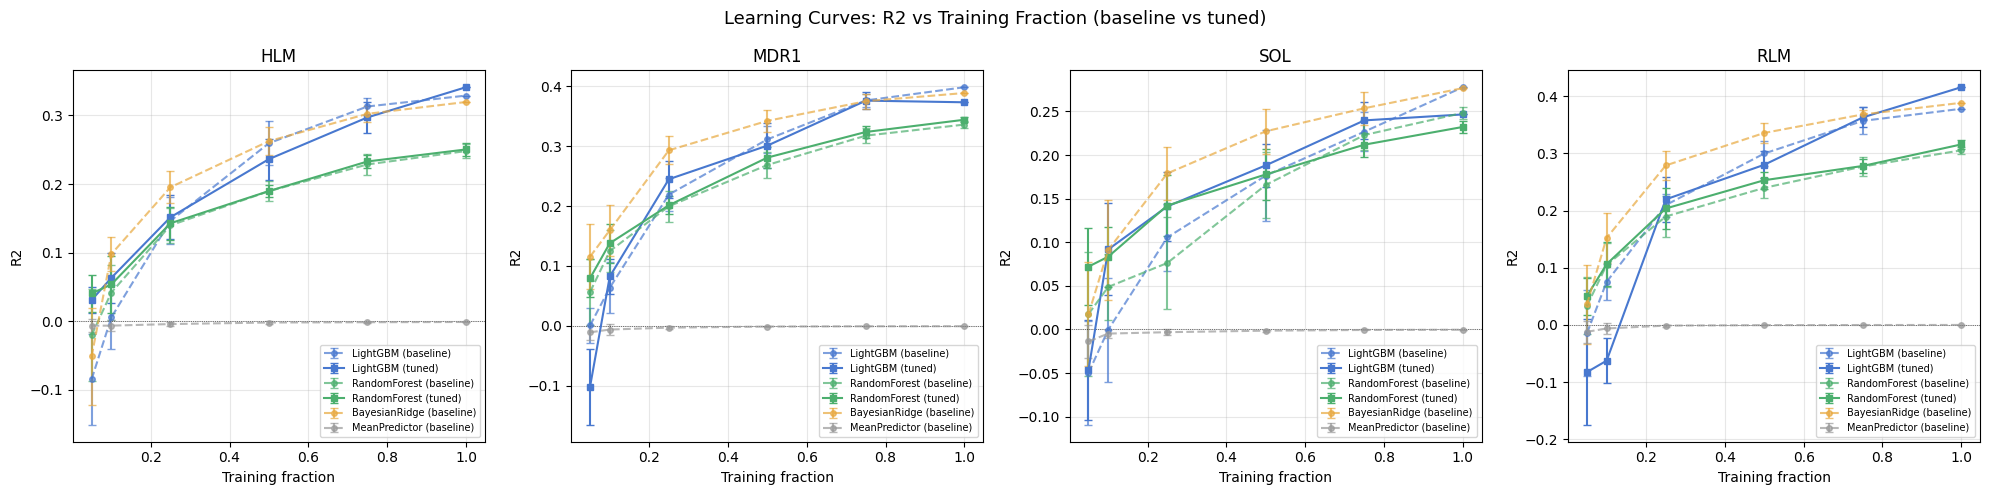

In [26]:
if lc_results.empty:
    print('No learning curve results to plot.')
else:
    MODEL_COLORS = {'LightGBM': '#4878cf', 'RandomForest': '#4caf6e',
                    'BayesianRidge': '#e8a83e', 'MeanPredictor': '#999999',
                    'MPNN2': '#c94a4a'}

    fig, axes = plt.subplots(1, len(EP_SHORT), figsize=(5 * len(EP_SHORT), 5), sharey=False)
    if len(EP_SHORT) == 1:
        axes = [axes]

    for ax, ep in zip(axes, EP_SHORT):
        ep_df = lc_results[lc_results["ep_short"] == ep]

        for model in ["LightGBM", "RandomForest", "BayesianRidge", "MeanPredictor", "MPNN2"]:
            color = MODEL_COLORS.get(model, "grey")

            # Baseline arm
            bl = ep_df[(ep_df["model"] == model) & (ep_df["arm"] == "baseline")]
            if not bl.empty:
                agg = bl.groupby("fraction")["R2"].agg(["mean", "std"])
                ax.errorbar(agg.index, agg["mean"], yerr=agg["std"].fillna(0),
                            color=color, linestyle="--", marker="o", markersize=4,
                            label=f"{model} (baseline)", alpha=0.7, capsize=3)

            # Tuned arm
            tn = ep_df[(ep_df["model"] == model) & (ep_df["arm"] == "tuned")]
            if not tn.empty:
                agg = tn.groupby("fraction")["R2"].agg(["mean", "std"])
                ax.errorbar(agg.index, agg["mean"], yerr=agg["std"].fillna(0),
                            color=color, linestyle="-", marker="s", markersize=4,
                            label=f"{model} (tuned)", capsize=3)

        ax.set_title(ep)
        ax.set_xlabel("Training fraction")
        ax.set_ylabel("R2")
        ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
        ax.legend(fontsize=7, loc="lower right")
        ax.grid(True, alpha=0.3)

    fig.suptitle('Learning Curves: R2 vs Training Fraction (baseline vs tuned)', fontsize=13)
    plt.tight_layout()
    fig.savefig('../figures/4.1_learning_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3. Noise Injection (Phase 5)

Inject label noise into training data at full N. Test set always clean.
Three noise types:
1. **Gaussian** (intra-assay): y + N(0, sigma * std)
2. **Systematic bias** (inter-assay): shift 50% of labels by c * std
3. **Gross errors** (annotation): replace k% of labels with uniform random

Two arms: baseline (default params) vs tuned (re-tune on noisy data).

In [ ]:
if not RUN_NOISE_INJECTION:
    import os
    _path = '../data/processed/noise_injection_results.csv'
    noise_results = pd.read_csv(_path) if os.path.exists(_path) else pd.DataFrame()
    print(f'Noise injection skipped — loaded {len(noise_results)} existing rows from disk.'
          if not noise_results.empty else 'Noise injection skipped (no existing results on disk).')
else:
    from sklearn.linear_model import BayesianRidge
    from sklearn.dummy import DummyRegressor
    from lightgbm import LGBMRegressor
    from sklearn.ensemble import RandomForestRegressor
    from src.tuning import make_model

    noise_rows = []

    # Build noise conditions: (noise_type, level, noise_fn)
    noise_conditions = []
    for sigma in GAUSSIAN_SIGMAS:
        noise_conditions.append(('gaussian', sigma,
            lambda y, s, rs: add_gaussian_noise(y, s, random_state=rs)))
    for bias in BIAS_FRACS:
        noise_conditions.append(('systematic_bias', bias,
            lambda y, s, rs: add_systematic_bias(y, s, random_state=rs)))
    for ef in GROSS_ERROR_FRACS:
        noise_conditions.append(('gross_error', ef,
            lambda y, s, rs: add_gross_errors(y, s, random_state=rs)))

    total = len(MODEL_ENDPOINTS) * len(noise_conditions) * N_SEEDS
    step = 0

    for col in MODEL_ENDPOINTS:
        ep_short = EP_SHORT_MAP[col]
        d = ep_data[col]
        X_train, X_test = d['X_train'], d['X_test']
        y_train, y_test = d['y_train'], d['y_test']

        for noise_type, noise_level, noise_fn in noise_conditions:
            # ── Tune ONCE per (endpoint, noise_condition) using reference noisy labels ──
            y_ref_noisy = noise_fn(y_train, noise_level, 99)
            X_tune_r, X_val_r, y_tune_r, y_val_r = train_test_split(
                X_train, y_ref_noisy, test_size=TUNE_VAL_FRAC, random_state=42
            )
            _, lgbm_params = tune_lightgbm(X_tune_r, y_tune_r, X_val_r, y_val_r,
                                           n_iter=TUNE_N_ITER, random_state=42)
            _, rf_params = tune_rf(X_tune_r, y_tune_r, X_val_r, y_val_r,
                                   n_iter=TUNE_N_ITER, random_state=42)
            print(f'  Tuned {ep_short} {noise_type} level={noise_level}')

            for seed in range(N_SEEDS):
                step += 1
                y_noisy = noise_fn(y_train, noise_level, seed)

                base = {
                    'endpoint': col, 'ep_short': ep_short,
                    'noise_type': noise_type, 'noise_level': noise_level, 'seed': seed,
                }

                # ── Baseline arm ──
                baseline_models = {
                    'MeanPredictor': DummyRegressor(strategy='mean'),
                    'BayesianRidge': BayesianRidge(),
                    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=seed, n_jobs=-1),
                    'LightGBM': LGBMRegressor(n_estimators=100, random_state=seed, verbose=-1),
                }
                for name, model in baseline_models.items():
                    model.fit(X_train, y_noisy)
                    metrics = evaluate_model(model, X_test, y_test)
                    noise_rows.append({**base, 'model': name, 'arm': 'baseline', **metrics})

                # ── Tuned arm: build from frozen params, fit on this seed's noisy labels ──
                tuned_lgbm = make_model('LightGBM', lgbm_params)
                tuned_lgbm.fit(X_train, y_noisy)
                metrics = evaluate_model(tuned_lgbm, X_test, y_test)
                noise_rows.append({**base, 'model': 'LightGBM', 'arm': 'tuned', **metrics})

                tuned_rf = make_model('RandomForest', rf_params)
                tuned_rf.fit(X_train, y_noisy)
                metrics = evaluate_model(tuned_rf, X_test, y_test)
                noise_rows.append({**base, 'model': 'RandomForest', 'arm': 'tuned', **metrics})

                # ── MPNN2: baseline (RMSE stopping) + tuned (MAE stopping) ──
                if RUN_MPNN2_EXPERIMENTS and seed < MPNN2_N_SEEDS:
                    smi_train_ep = ep_data[col]['smi_train']
                    smi_test_ep  = ep_data[col]['smi_test']
                    for arm_label, metric in [('baseline', 'rmse'), ('tuned', 'mae')]:
                        run_dir = f'../models/mpnn2_exp/noise/{ep_short}/{noise_type}/{noise_level}/seed{seed}/{arm_label}'
                        y_pred_mpnn2 = _run_mpnn2(smi_train_ep, y_noisy, smi_test_ep, run_dir, metric=metric)
                        metrics = evaluate_model(None, None, y_test, y_pred=y_pred_mpnn2)
                        noise_rows.append({**base, 'model': 'MPNN2', 'arm': arm_label, **metrics})

                if step % 20 == 0 or step == total:
                    print(f'    [{step}/{total}] {ep_short} {noise_type} level={noise_level} seed={seed}')

    noise_results = pd.DataFrame(noise_rows)
    print(f'\nNoise injection done: {len(noise_results)} result rows')

### 3.1 Noise Injection Summary

In [8]:
if noise_results.empty:
    print('No noise results.')
else:
    for nt in ['gaussian', 'systematic_bias', 'gross_error']:
        print(f'\n=== {nt.upper()} ===')
        sub = noise_results[noise_results['noise_type'] == nt]
        summary = sub.groupby(['ep_short', 'model', 'arm', 'noise_level'])['R2'].agg(['mean', 'std']).reset_index()
        summary.columns = ["ep_short", "model", "arm", "noise_level", "R2_mean", "R2_std"]
        print(summary.to_string(index=False))


=== GAUSSIAN ===
ep_short         model      arm  noise_level   R2_mean   R2_std
     HLM BayesianRidge baseline          0.0  0.319680 0.000000
     HLM BayesianRidge baseline          0.1  0.317646 0.002105
     HLM BayesianRidge baseline          0.3  0.307602 0.006233
     HLM BayesianRidge baseline          0.5  0.291589 0.010167
     HLM BayesianRidge baseline          1.0  0.241573 0.018835
     HLM      LightGBM baseline          0.0  0.329000 0.000000
     HLM      LightGBM baseline          0.1  0.327325 0.007972
     HLM      LightGBM baseline          0.3  0.315210 0.013674
     HLM      LightGBM baseline          0.5  0.297879 0.020033
     HLM      LightGBM baseline          1.0  0.183792 0.038135
     HLM      LightGBM    tuned          0.0  0.320075 0.000000
     HLM      LightGBM    tuned          0.1  0.339442 0.009899
     HLM      LightGBM    tuned          0.3  0.338459 0.011898
     HLM      LightGBM    tuned          0.5  0.320830 0.018000
     HLM      LightGBM

### 3.2 Noise Degradation Plots

R2 vs noise level, one row per noise type, one column per endpoint.

### 3.2a Theoretical Gaussian Noise Ceiling

`NoiseEstimator` (ChemRxiv 2024; doi:10.26434/chemrxiv-2024-z0pz7) bootstraps
R²(y_clean, y_noisy) — the R² a *perfect predictor of clean labels* scores when **evaluated against noisy labels**.

Analytically: **R² = 1 − σ²/Var(y)**

| σ_frac | Ceiling R² |
|--------|-----------|
| 0.0 | 1.00 |
| 0.1 | 0.99 |
| 0.3 | 0.91 |
| 0.5 | 0.75 |
| 1.0 | 0 |

**Only applicable to Gaussian noise** — systematic bias and gross errors are not supported by this library.

In [9]:
# ── Theoretical Gaussian noise ceiling via NoiseEstimator ──
# Corradi & van Hilten, ChemRxiv 2024. doi:10.26434/chemrxiv-2024-z0pz7
# Computes R²(y_clean, y_noisy) = 1 - σ²/Var(y) by bootstrap.
# This is the best R² a perfect clean-label predictor achieves when *evaluated against noisy labels*.

if noise_results.empty:
    print('No noise results — skipping ceiling computation.')
    ceiling_by_ep = {}
else:
    import pandas as pd
    from noiseestimator import NoiseEstimator as NE

    ceiling_by_ep = {}
    for col in MODEL_ENDPOINTS:
        ep_short = EP_SHORT_MAP[col]
        y_tr = ep_data[col]['y_train']
        y_s = pd.Series(y_tr)
        sigma_abs = [f * y_s.std() for f in GAUSSIAN_SIGMAS]

        ne = NE(dataset=y_s, noise_levels=sigma_abs, noise_type='gaussian', n_bootstrap=1000)
        df_boot = ne.noise_bootstraps.copy()
        # Map noise label back to sigma_frac
        noise_label_to_frac = {f'noise_{s}': frac for s, frac in zip(sigma_abs, GAUSSIAN_SIGMAS)}
        df_boot['sigma_frac'] = df_boot['noise'].map(noise_label_to_frac)
        ceiling_by_ep[ep_short] = df_boot

        summary = df_boot.groupby('sigma_frac')['r2'].agg(
            median='median',
            p5=lambda x: x.quantile(0.05),
            p95=lambda x: x.quantile(0.95),
        )
        print(f'{ep_short} ceiling (R² = 1 - σ²/Var(y)):')
        print(summary.to_string())
        print()

    print('Ceiling computed for', list(ceiling_by_ep.keys()))

HLM ceiling (R² = 1 - σ²/Var(y)):
              median        p5       p95
sigma_frac                              
0.0         1.000000  1.000000  1.000000
0.1         0.989995  0.989532  0.990479
0.3         0.909877  0.905594  0.914019
0.5         0.749436  0.736722  0.761414
1.0         0.000146 -0.046029  0.044698

MDR1 ceiling (R² = 1 - σ²/Var(y)):
              median        p5       p95
sigma_frac                              
0.0         1.000000  1.000000  1.000000
0.1         0.990013  0.989508  0.990514
0.3         0.909966  0.905255  0.914668
0.5         0.749660  0.737346  0.762607
1.0         0.000144 -0.049970  0.048172

SOL ceiling (R² = 1 - σ²/Var(y)):
              median        p5       p95
sigma_frac                              
0.0         1.000000  1.000000  1.000000
0.1         0.989998  0.989435  0.990527
0.3         0.909944  0.904914  0.914912
0.5         0.749869  0.735784  0.764026
1.0        -0.001517 -0.057886  0.055627

RLM ceiling (R² = 1 - σ²/Var(y)):

> **Interpretation note**: Model curves in the Gaussian plots below sit *above* the ceiling because the project keeps the test set clean — a model that perfectly learns clean labels still scores high R² on a clean test regardless of training noise. The ceiling binds on two things: (a) **CV scores during tuning** — `RandomizedSearchCV` folds inherit training noise, so the ceiling tells you whether the tuner is being guided by signal; (b) **field-deployment performance** — if held-out measurements carry the same noise σ as training data, the ceiling is the best achievable deployed R².

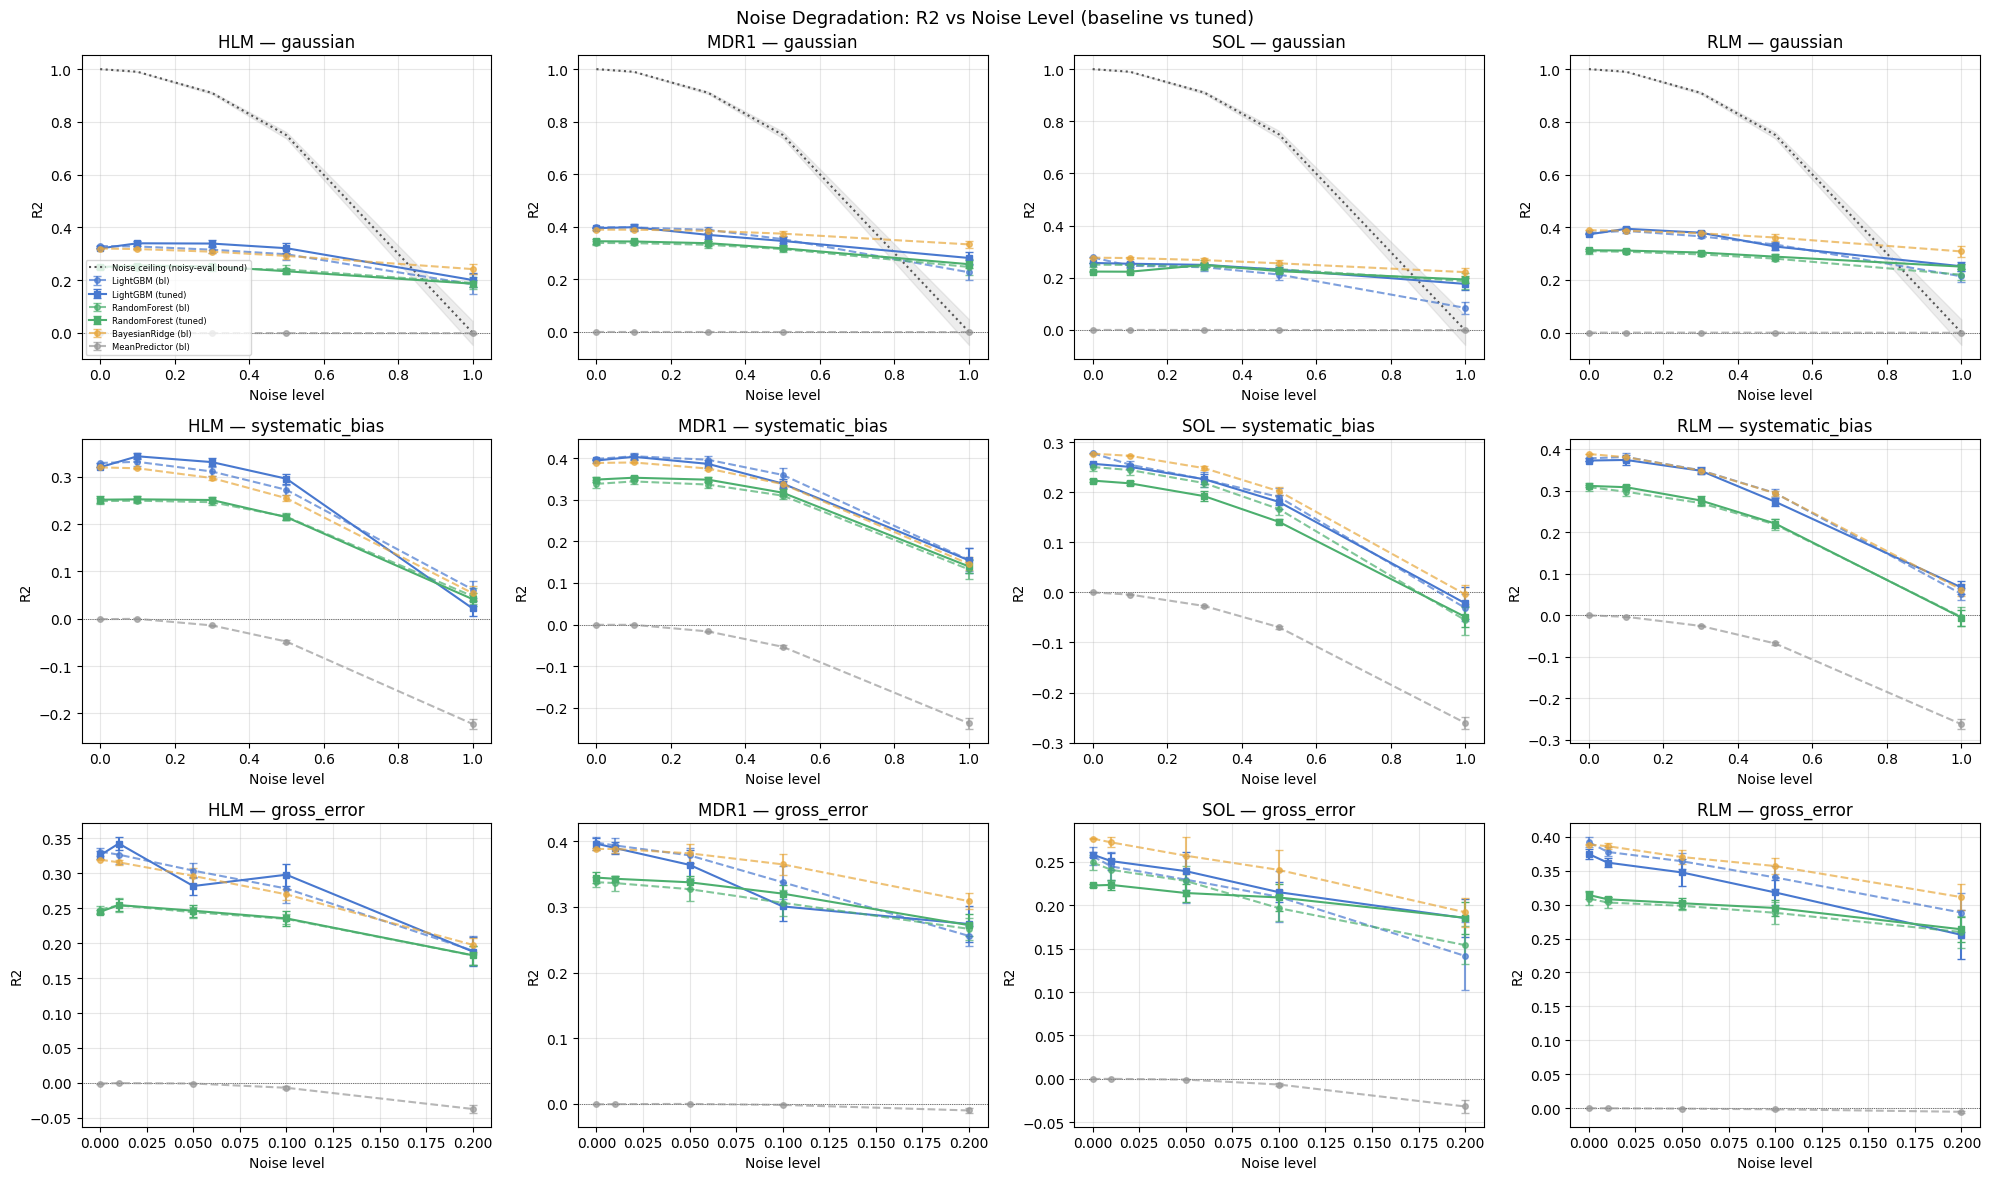

In [21]:
if noise_results.empty:
    print('No noise results to plot.')
else:
    MODEL_COLORS = {'LightGBM': '#4878cf', 'RandomForest': '#4caf6e',
                    'BayesianRidge': '#e8a83e', 'MeanPredictor': '#999999',
                    'MPNN2': '#c94a4a'}
    noise_types = ['gaussian', 'systematic_bias', 'gross_error']

    fig, axes = plt.subplots(len(noise_types), len(EP_SHORT),
                             figsize=(5 * len(EP_SHORT), 4 * len(noise_types)), sharey=False)

    for row, nt in enumerate(noise_types):
        nt_df = noise_results[noise_results['noise_type'] == nt]
        for col_idx, ep in enumerate(EP_SHORT):
            ax = axes[row, col_idx]
            ep_df = nt_df[nt_df["ep_short"] == ep]

            for model in ["LightGBM", "RandomForest", "BayesianRidge", "MeanPredictor", "MPNN2"]:
                color = MODEL_COLORS.get(model, "grey")

                bl = ep_df[(ep_df["model"] == model) & (ep_df["arm"] == "baseline")]
                if not bl.empty:
                    agg = bl.groupby("noise_level")["R2"].agg(["mean", "std"])
                    ax.errorbar(agg.index, agg["mean"], yerr=agg["std"].fillna(0),
                                color=color, linestyle="--", marker="o", markersize=4,
                                label=f"{model} (bl)", alpha=0.7, capsize=3)

                tn = ep_df[(ep_df["model"] == model) & (ep_df["arm"] == "tuned")]
                if not tn.empty:
                    agg = tn.groupby("noise_level")["R2"].agg(["mean", "std"])
                    ax.errorbar(agg.index, agg["mean"], yerr=agg["std"].fillna(0),
                                color=color, linestyle="-", marker="s", markersize=4,
                                label=f"{model} (tuned)", capsize=3)

            # ── Gaussian ceiling overlay (Gaussian noise type only) ──
            if nt == 'gaussian' and ceiling_by_ep and ep in ceiling_by_ep:
                c_df = ceiling_by_ep[ep].groupby('sigma_frac')['r2'].agg(
                    median='median',
                    p5=lambda x: x.quantile(0.05),
                    p95=lambda x: x.quantile(0.95),
                ).reset_index()
                ax.plot(c_df['sigma_frac'], c_df['median'],
                        color='#555555', linestyle=':', linewidth=1.5,
                        label='Noise ceiling (noisy-eval bound)')
                ax.fill_between(c_df['sigma_frac'], c_df['p5'], c_df['p95'],
                                color='#555555', alpha=0.10)

            ax.set_title(f"{ep} — {nt}")
            ax.set_xlabel("Noise level")
            ax.set_ylabel("R2")
            ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
            ax.grid(True, alpha=0.3)
            if row == 0 and col_idx == 0:
                ax.legend(fontsize=6, loc="lower left")
            elif nt == 'gaussian' and col_idx == 0:
                ax.legend(fontsize=6, loc="lower left")

    fig.suptitle('Noise Degradation: R2 vs Noise Level (baseline vs tuned)', fontsize=13)
    plt.tight_layout()
    fig.savefig('../figures/5.1_noise_degradation.png', dpi=150, bbox_inches='tight')
    plt.show()

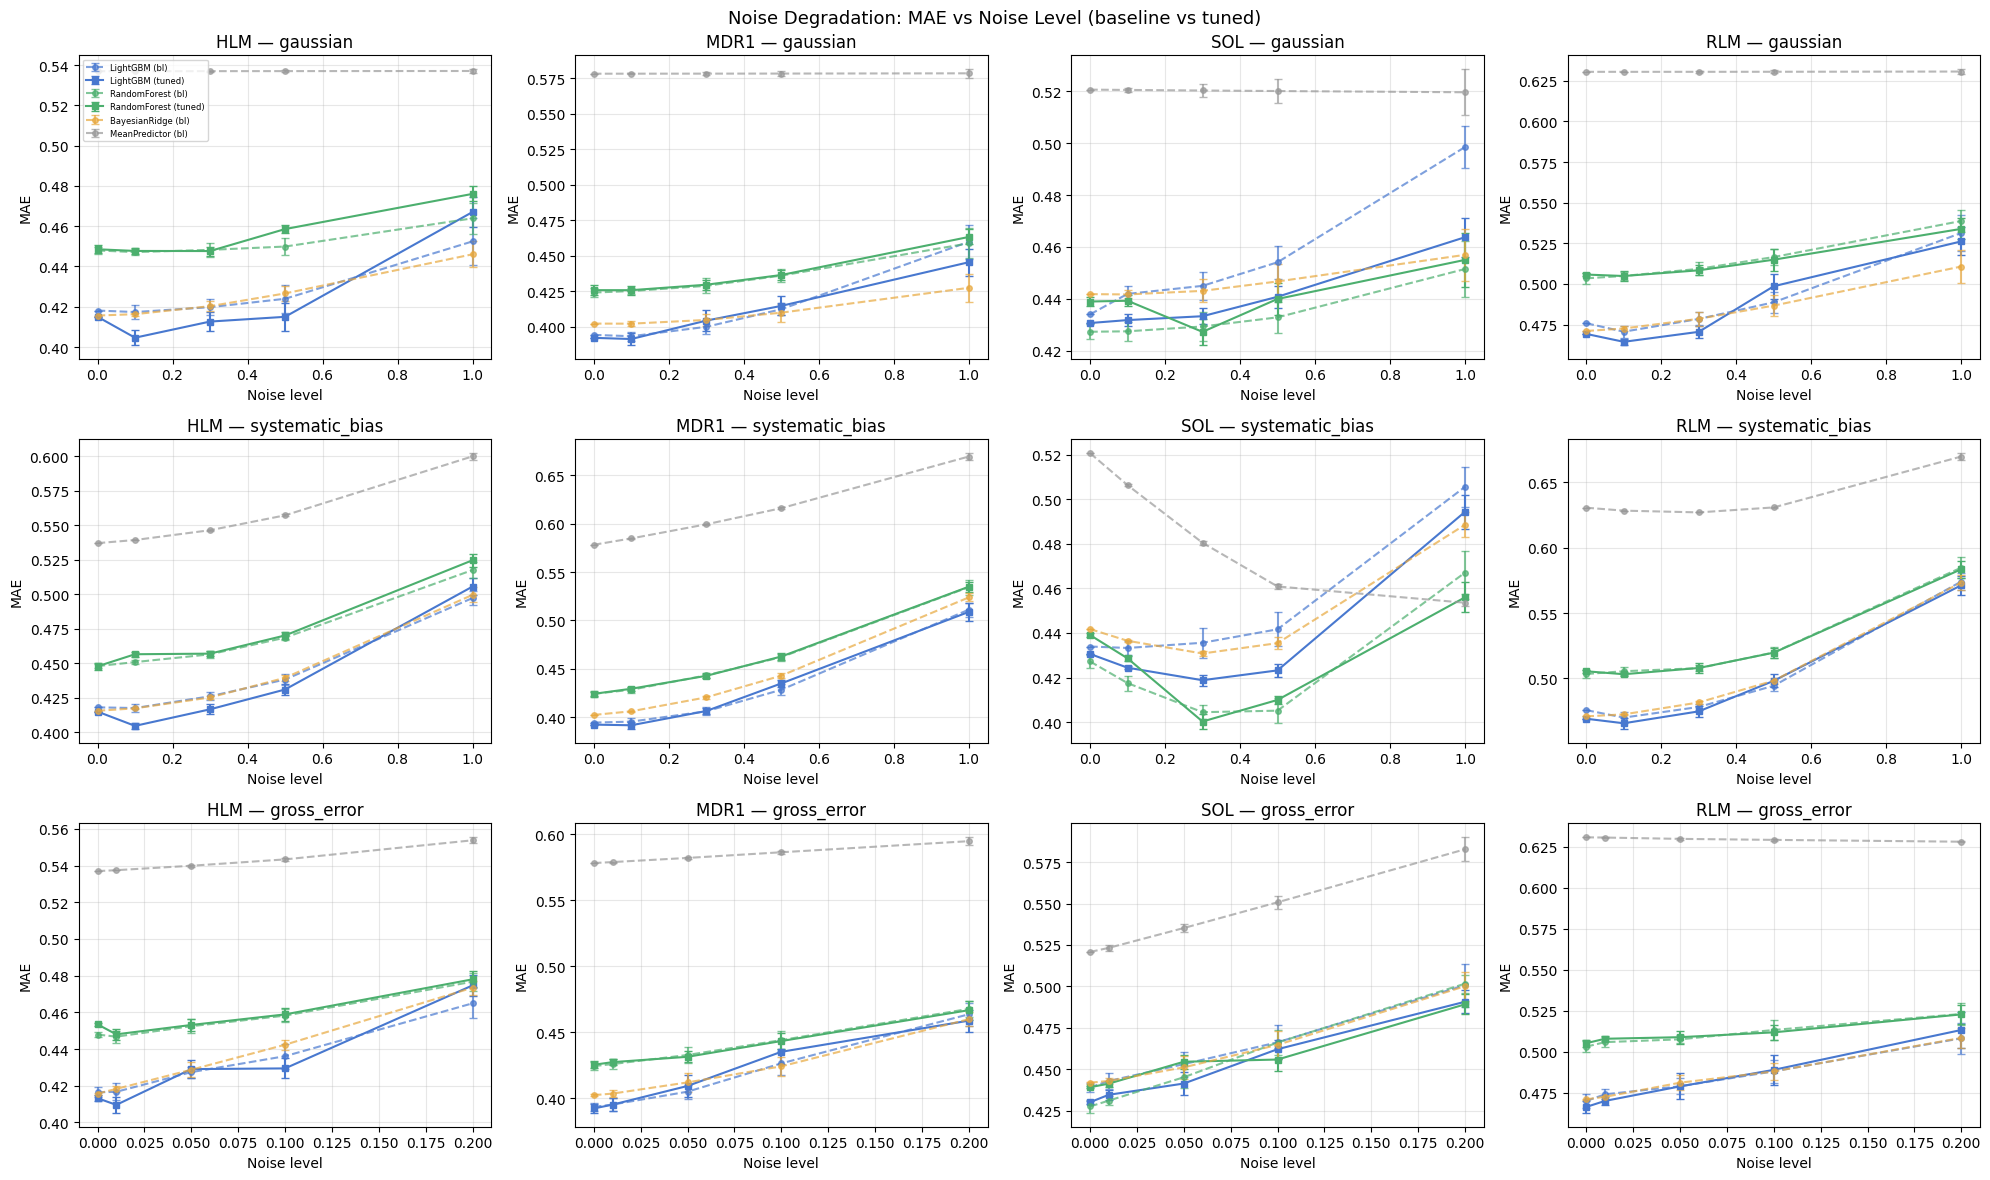

In [27]:
if noise_results.empty:
    print('No noise results to plot.')
else:
    MODEL_COLORS = {'LightGBM': '#4878cf', 'RandomForest': '#4caf6e',
                    'BayesianRidge': '#e8a83e', 'MeanPredictor': '#999999',
                    'MPNN2': '#c94a4a'}
    noise_types = ['gaussian', 'systematic_bias', 'gross_error']

    fig, axes = plt.subplots(len(noise_types), len(EP_SHORT),
                             figsize=(5 * len(EP_SHORT), 4 * len(noise_types)), sharey=False)

    for row, nt in enumerate(noise_types):
        nt_df = noise_results[noise_results['noise_type'] == nt]
        for col_idx, ep in enumerate(EP_SHORT):
            ax = axes[row, col_idx]
            ep_df = nt_df[nt_df["ep_short"] == ep]

            for model in ["LightGBM", "RandomForest", "BayesianRidge", "MeanPredictor", "MPNN2"]:
                color = MODEL_COLORS.get(model, "grey")

                bl = ep_df[(ep_df["model"] == model) & (ep_df["arm"] == "baseline")]
                if not bl.empty:
                    agg = bl.groupby("noise_level")["MAE"].agg(["mean", "std"])
                    ax.errorbar(agg.index, agg["mean"], yerr=agg["std"].fillna(0),
                                color=color, linestyle="--", marker="o", markersize=4,
                                label=f"{model} (bl)", alpha=0.7, capsize=3)

                tn = ep_df[(ep_df["model"] == model) & (ep_df["arm"] == "tuned")]
                if not tn.empty:
                    agg = tn.groupby("noise_level")["MAE"].agg(["mean", "std"])
                    ax.errorbar(agg.index, agg["mean"], yerr=agg["std"].fillna(0),
                                color=color, linestyle="-", marker="s", markersize=4,
                                label=f"{model} (tuned)", capsize=3)

            ax.set_title(f"{ep} — {nt}")
            ax.set_xlabel("Noise level")
            ax.set_ylabel("MAE")
            ax.grid(True, alpha=0.3)
            if row == 0 and col_idx == 0:
                ax.legend(fontsize=6, loc="upper left")

    fig.suptitle('Noise Degradation: MAE vs Noise Level (baseline vs tuned)', fontsize=13)
    plt.tight_layout()
    fig.savefig('../figures/5.2_noise_degradation_mae.png', dpi=150, bbox_inches='tight')
    plt.show()

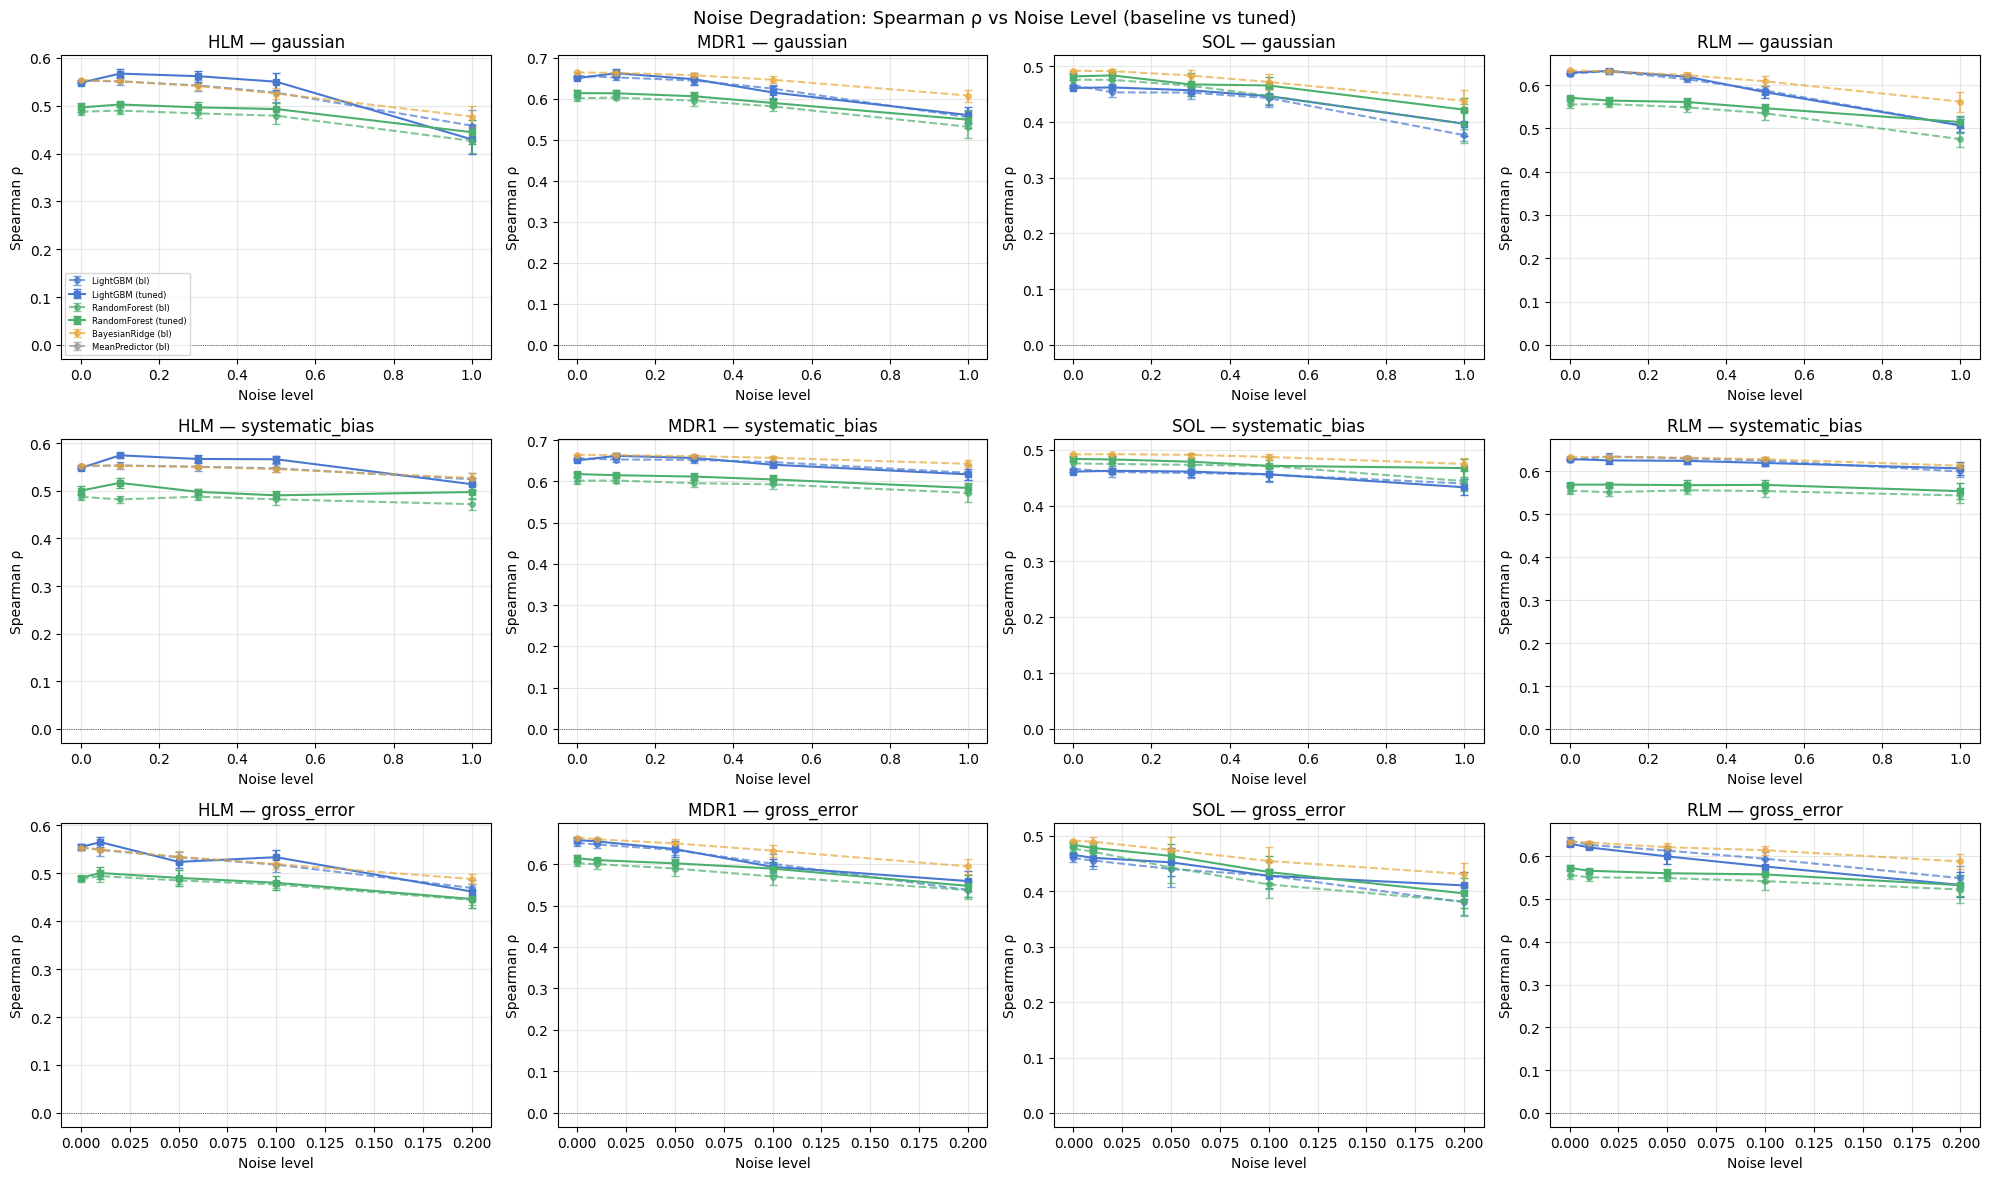

In [28]:
if noise_results.empty:
    print('No noise results to plot.')
else:
    MODEL_COLORS = {'LightGBM': '#4878cf', 'RandomForest': '#4caf6e',
                    'BayesianRidge': '#e8a83e', 'MeanPredictor': '#999999',
                    'MPNN2': '#c94a4a'}
    noise_types = ['gaussian', 'systematic_bias', 'gross_error']

    fig, axes = plt.subplots(len(noise_types), len(EP_SHORT),
                             figsize=(5 * len(EP_SHORT), 4 * len(noise_types)), sharey=False)

    for row, nt in enumerate(noise_types):
        nt_df = noise_results[noise_results['noise_type'] == nt]
        for col_idx, ep in enumerate(EP_SHORT):
            ax = axes[row, col_idx]
            ep_df = nt_df[nt_df["ep_short"] == ep]

            for model in ["LightGBM", "RandomForest", "BayesianRidge", "MeanPredictor", "MPNN2"]:
                color = MODEL_COLORS.get(model, "grey")

                bl = ep_df[(ep_df["model"] == model) & (ep_df["arm"] == "baseline")]
                if not bl.empty:
                    agg = bl.groupby("noise_level")["Spearman"].agg(["mean", "std"])
                    ax.errorbar(agg.index, agg["mean"], yerr=agg["std"].fillna(0),
                                color=color, linestyle="--", marker="o", markersize=4,
                                label=f"{model} (bl)", alpha=0.7, capsize=3)

                tn = ep_df[(ep_df["model"] == model) & (ep_df["arm"] == "tuned")]
                if not tn.empty:
                    agg = tn.groupby("noise_level")["Spearman"].agg(["mean", "std"])
                    ax.errorbar(agg.index, agg["mean"], yerr=agg["std"].fillna(0),
                                color=color, linestyle="-", marker="s", markersize=4,
                                label=f"{model} (tuned)", capsize=3)

            ax.set_title(f"{ep} — {nt}")
            ax.set_xlabel("Noise level")
            ax.set_ylabel("Spearman ρ")
            ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
            ax.grid(True, alpha=0.3)
            if row == 0 and col_idx == 0:
                ax.legend(fontsize=6, loc="lower left")

    fig.suptitle('Noise Degradation: Spearman ρ vs Noise Level (baseline vs tuned)', fontsize=13)
    plt.tight_layout()
    fig.savefig('../figures/5.3_noise_degradation_spearman.png', dpi=150, bbox_inches='tight')
    plt.show()

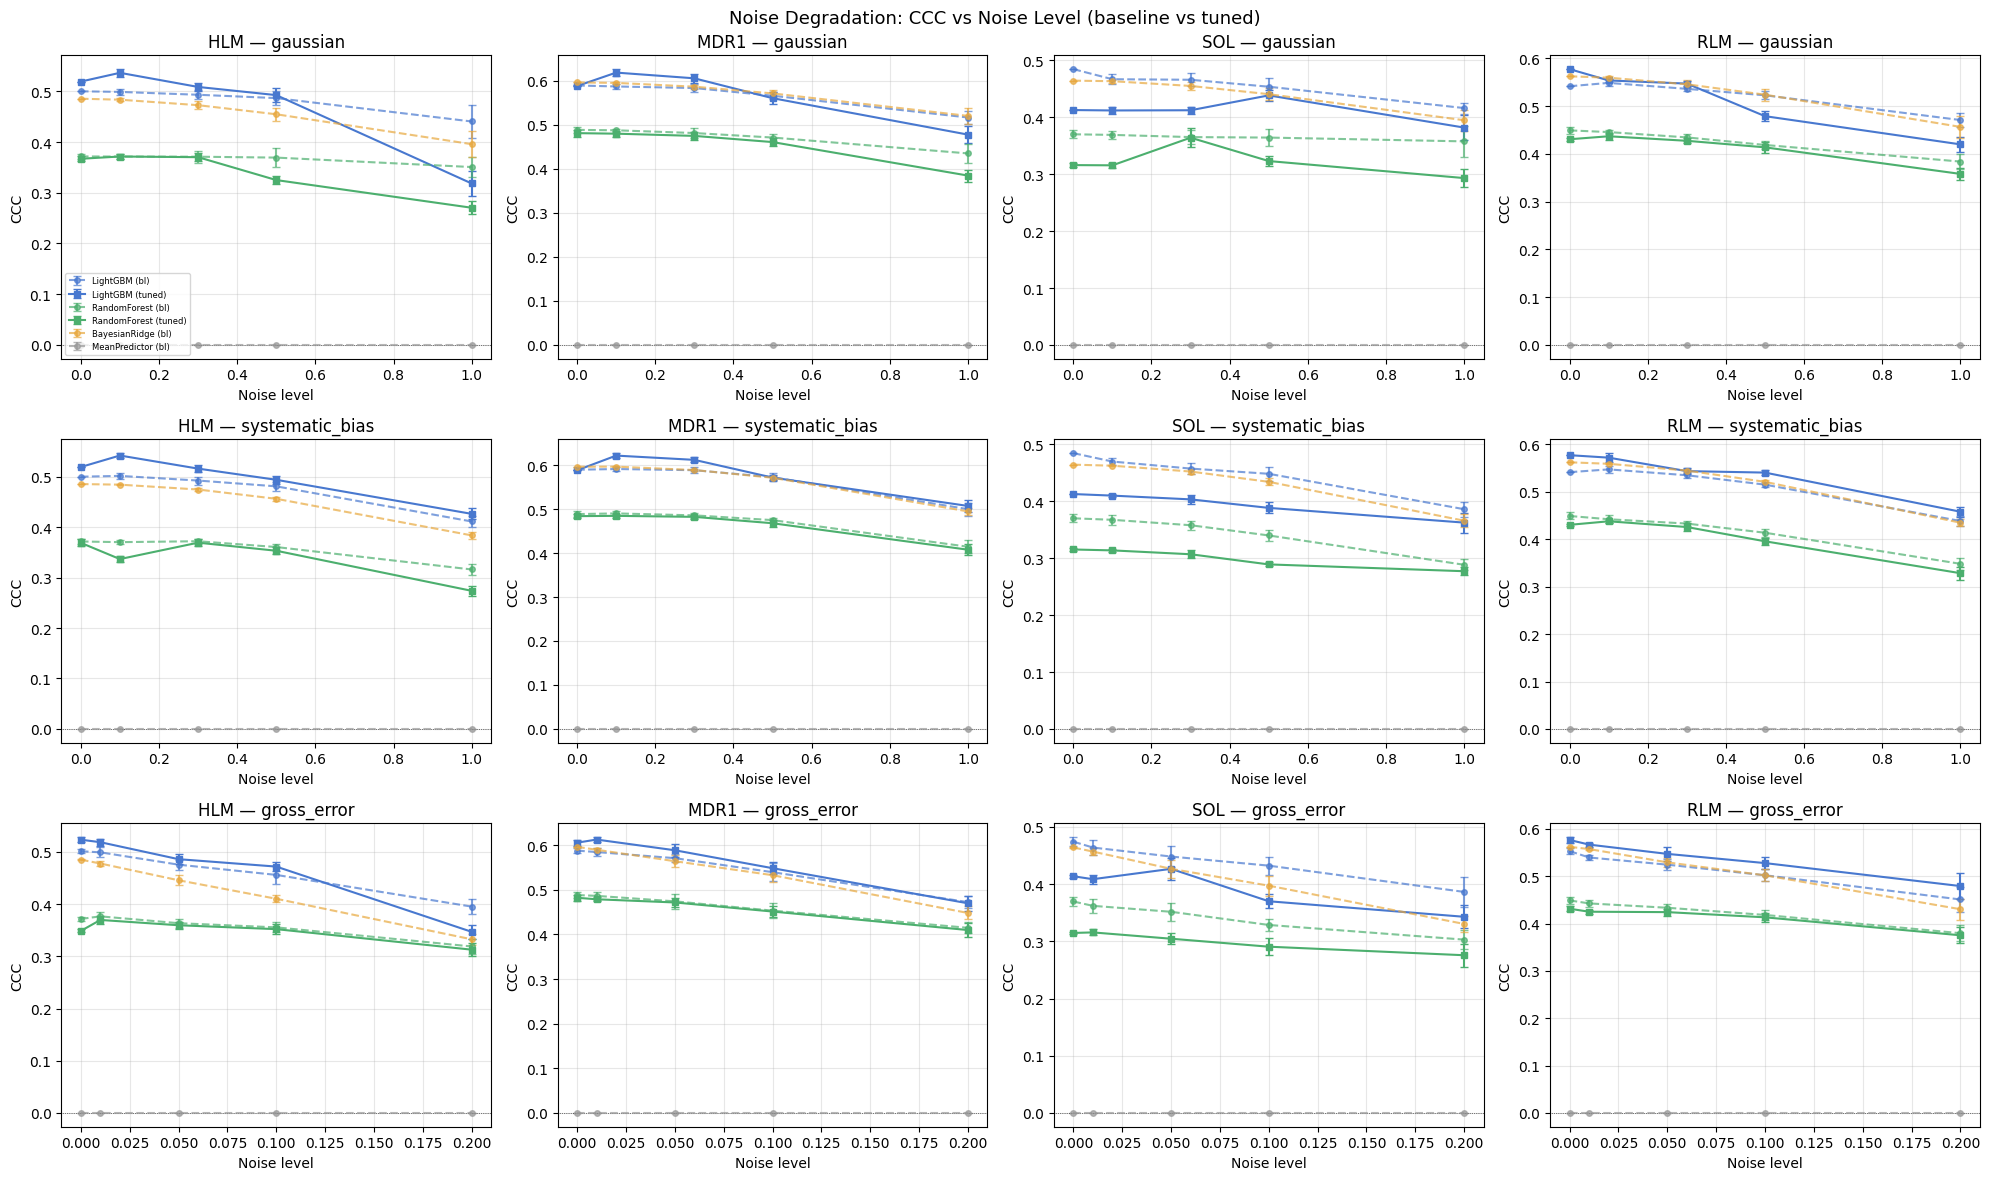

In [29]:
if noise_results.empty:
    print('No noise results to plot.')
else:
    MODEL_COLORS = {'LightGBM': '#4878cf', 'RandomForest': '#4caf6e',
                    'BayesianRidge': '#e8a83e', 'MeanPredictor': '#999999',
                    'MPNN2': '#c94a4a'}
    noise_types = ['gaussian', 'systematic_bias', 'gross_error']

    fig, axes = plt.subplots(len(noise_types), len(EP_SHORT),
                             figsize=(5 * len(EP_SHORT), 4 * len(noise_types)), sharey=False)

    for row, nt in enumerate(noise_types):
        nt_df = noise_results[noise_results['noise_type'] == nt]
        for col_idx, ep in enumerate(EP_SHORT):
            ax = axes[row, col_idx]
            ep_df = nt_df[nt_df["ep_short"] == ep]

            for model in ["LightGBM", "RandomForest", "BayesianRidge", "MeanPredictor", "MPNN2"]:
                color = MODEL_COLORS.get(model, "grey")

                bl = ep_df[(ep_df["model"] == model) & (ep_df["arm"] == "baseline")]
                if not bl.empty:
                    agg = bl.groupby("noise_level")["CCC"].agg(["mean", "std"])
                    ax.errorbar(agg.index, agg["mean"], yerr=agg["std"].fillna(0),
                                color=color, linestyle="--", marker="o", markersize=4,
                                label=f"{model} (bl)", alpha=0.7, capsize=3)

                tn = ep_df[(ep_df["model"] == model) & (ep_df["arm"] == "tuned")]
                if not tn.empty:
                    agg = tn.groupby("noise_level")["CCC"].agg(["mean", "std"])
                    ax.errorbar(agg.index, agg["mean"], yerr=agg["std"].fillna(0),
                                color=color, linestyle="-", marker="s", markersize=4,
                                label=f"{model} (tuned)", capsize=3)

            ax.set_title(f"{ep} — {nt}")
            ax.set_xlabel("Noise level")
            ax.set_ylabel("CCC")
            ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
            ax.grid(True, alpha=0.3)
            if row == 0 and col_idx == 0:
                ax.legend(fontsize=6, loc="lower left")

    fig.suptitle('Noise Degradation: CCC vs Noise Level (baseline vs tuned)', fontsize=13)
    plt.tight_layout()
    fig.savefig('../figures/5.4_noise_degradation_ccc.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Save Results

In [11]:
# Save raw results for Phase 6 surface plots
import os
os.makedirs('../data/processed', exist_ok=True)

if not lc_results.empty:
    lc_results.to_csv('../data/processed/learning_curve_results.csv', index=False)
    print(f'Saved learning curve results: {len(lc_results)} rows')

if not noise_results.empty:
    noise_results.to_csv('../data/processed/noise_injection_results.csv', index=False)
    print(f'Saved noise injection results: {len(noise_results)} rows')

Saved learning curve results: 1440 rows
Saved noise injection results: 3600 rows


## 5. Phase 5b — Validation Set Quality Sub-Experiment

Compare two tuning regimes at 3 training sizes ({5%, 25%, 100%}) across all noise levels:
- **Arm A (realistic — noisy val)**: inject noise into full subsample, split noisy into pool + noisy val, tune
- **Arm B (ideal — clean val)**: split clean first (pool 80% + clean val 20%), inject noise into pool only, tune with clean val

Both arms fit the final model on the **same full noisy subsample** — the only difference is HP selection.
Baseline (default HPs, no val set) included for reference.

**Key question**: how large is Δ R² = R²(Arm B) − R²(Arm A)? Does a clean val set materially improve tuning under noise?

**MPNN2 note**: For sklearn models (LightGBM, RF), HP search runs on pool→val and the final model retrains on pool+val (full subsample). For ChemProp/MPNN2, the val set is consumed during early stopping — there is no separate retraining step — so MPNN2 A/B_tuned train on ~80% of the subsample (the pool only). This does not confound the Δ R² comparison: both arms use the same pool size and the delta is computed within-model. Cross-model absolute R² comparisons in Phase 5b should account for this difference.


In [ ]:
RUN_PHASE5B = True
FRACS_5B = [0.05, 0.25, 1.0]

In [ ]:
if not RUN_PHASE5B:
    import os
    _path = '../data/processed/phase5b_results.csv'
    phase5b_results = pd.read_csv(_path) if os.path.exists(_path) else pd.DataFrame()
    print(f'Phase 5b skipped — loaded {len(phase5b_results)} existing rows.'
          if not phase5b_results.empty else 'Phase 5b skipped (no existing results on disk).')
else:
    from sklearn.linear_model import BayesianRidge
    from sklearn.dummy import DummyRegressor
    from lightgbm import LGBMRegressor
    from sklearn.ensemble import RandomForestRegressor
    from src.tuning import make_model

    # Noise conditions — same as Phase 5
    noise_conditions_5b = []
    for sigma in GAUSSIAN_SIGMAS:
        noise_conditions_5b.append(('gaussian', sigma,
            lambda y, s, rs: add_gaussian_noise(y, s, random_state=rs)))
    for bias in BIAS_FRACS:
        noise_conditions_5b.append(('systematic_bias', bias,
            lambda y, s, rs: add_systematic_bias(y, s, random_state=rs)))
    for ef in GROSS_ERROR_FRACS:
        noise_conditions_5b.append(('gross_error', ef,
            lambda y, s, rs: add_gross_errors(y, s, random_state=rs)))

    phase5b_rows = []
    total_5b = len(MODEL_ENDPOINTS) * len(FRACS_5B) * len(noise_conditions_5b) * N_SEEDS
    step_5b = 0

    for col in MODEL_ENDPOINTS:
        ep_short = EP_SHORT_MAP[col]
        d = ep_data[col]
        X_train, X_test = d['X_train'], d['X_test']
        y_train, y_test = d['y_train'], d['y_test']

        for frac in FRACS_5B:
            n_sub = max(int(len(X_train) * frac), 10)
            idx_ref = np.random.RandomState(99).choice(len(X_train), n_sub, replace=False)
            X_sub_ref, y_sub_ref = X_train[idx_ref], y_train[idx_ref]

            for noise_type, noise_level, noise_fn in noise_conditions_5b:
                # ── Arm A tuning ref: inject noise into all, split noisy ──
                y_ref_noisy = noise_fn(y_sub_ref, noise_level, 99)
                X_ra, X_va, y_ra, y_va = train_test_split(
                    X_sub_ref, y_ref_noisy, test_size=TUNE_VAL_FRAC, random_state=42
                )
                _, lgbm_params_a = tune_lightgbm(X_ra, y_ra, X_va, y_va,
                                                  n_iter=TUNE_N_ITER, random_state=42)
                _, rf_params_a = tune_rf(X_ra, y_ra, X_va, y_va,
                                         n_iter=TUNE_N_ITER, random_state=42)

                # ── Arm B tuning ref: split CLEAN first, inject noise into pool only ──
                X_rb, X_vb, y_rb_clean, y_vb_clean = train_test_split(
                    X_sub_ref, y_sub_ref, test_size=TUNE_VAL_FRAC, random_state=42
                )
                y_rb_noisy = noise_fn(y_rb_clean, noise_level, 99)
                _, lgbm_params_b = tune_lightgbm(X_rb, y_rb_noisy, X_vb, y_vb_clean,
                                                  n_iter=TUNE_N_ITER, random_state=42)
                _, rf_params_b = tune_rf(X_rb, y_rb_noisy, X_vb, y_vb_clean,
                                         n_iter=TUNE_N_ITER, random_state=42)

                print(f'  Tuned {ep_short} frac={frac} {noise_type} level={noise_level}')

                for seed in range(N_SEEDS):
                    step_5b += 1
                    rng = np.random.RandomState(seed)
                    idx = rng.choice(len(X_train), n_sub, replace=False)
                    X_sub, y_sub_clean = X_train[idx], y_train[idx]
                    y_sub_noisy = noise_fn(y_sub_clean, noise_level, seed)

                    base = {
                        'endpoint': col, 'ep_short': ep_short,
                        'fraction': frac, 'n_train': n_sub,
                        'noise_type': noise_type, 'noise_level': noise_level, 'seed': seed,
                    }

                    # ── Baseline (default HPs, full noisy subsample) ──
                    for name, ModelCls, kwargs in [
                        ('MeanPredictor', DummyRegressor, {'strategy': 'mean'}),
                        ('BayesianRidge', BayesianRidge, {}),
                        ('RandomForest', RandomForestRegressor,
                         {'n_estimators': 100, 'random_state': seed, 'n_jobs': -1}),
                        ('LightGBM', LGBMRegressor,
                         {'n_estimators': 100, 'random_state': seed, 'verbose': -1}),
                    ]:
                        m = ModelCls(**kwargs)
                        m.fit(X_sub, y_sub_noisy)
                        metrics = evaluate_model(m, X_test, y_test)
                        phase5b_rows.append({**base, 'model': name, 'arm': 'baseline', **metrics})

                    # ── Arm A tuned: noisy val HP selection → fit on full noisy subsample ──
                    for name, params in [('LightGBM', lgbm_params_a), ('RandomForest', rf_params_a)]:
                        m = make_model(name, params)
                        m.fit(X_sub, y_sub_noisy)
                        metrics = evaluate_model(m, X_test, y_test)
                        phase5b_rows.append({**base, 'model': name, 'arm': 'A_tuned', **metrics})

                    # ── Arm B tuned: clean val HP selection → fit on full noisy subsample ──
                    for name, params in [('LightGBM', lgbm_params_b), ('RandomForest', rf_params_b)]:
                        m = make_model(name, params)
                        m.fit(X_sub, y_sub_noisy)
                        metrics = evaluate_model(m, X_test, y_test)
                        phase5b_rows.append({**base, 'model': name, 'arm': 'B_tuned', **metrics})

                    # ── MPNN2: baseline + Arm A (noisy val) + Arm B (clean val) ──
                    if RUN_MPNN2_EXPERIMENTS and seed < MPNN2_N_SEEDS:
                        smi_sub = [ep_data[col]['smi_train'][i] for i in idx]
                        smi_test_ep = ep_data[col]['smi_test']

                        # Baseline: full noisy subsample, ChemProp internal val split, RMSE stopping
                        run_dir = f'../models/mpnn2_exp/phase5b/{ep_short}/{noise_type}/{noise_level}/seed{seed}/baseline'
                        y_pred = _run_mpnn2(smi_sub, y_sub_noisy, smi_test_ep, run_dir, metric='rmse')
                        phase5b_rows.append({**base, 'model': 'MPNN2', 'arm': 'baseline',
                                             **evaluate_model(None, None, y_test, y_pred=y_pred)})

                        # Arm A (realistic): noisy pool + noisy val, MAE stopping
                        smi_pool_a, smi_val_a, y_pool_a, y_val_a = train_test_split(
                            smi_sub, y_sub_noisy, test_size=TUNE_VAL_FRAC, random_state=42
                        )
                        run_dir = f'../models/mpnn2_exp/phase5b/{ep_short}/{noise_type}/{noise_level}/seed{seed}/A_tuned'
                        y_pred = _run_mpnn2(smi_pool_a, y_pool_a, smi_test_ep, run_dir, metric='mae',
                                            smi_val=smi_val_a, y_val=y_val_a)
                        phase5b_rows.append({**base, 'model': 'MPNN2', 'arm': 'A_tuned',
                                             **evaluate_model(None, None, y_test, y_pred=y_pred)})

                        # Arm B (ideal): split clean first → noise pool only → clean val, MAE stopping
                        smi_pool_b, smi_val_b, y_pool_b_clean, y_val_b_clean = train_test_split(
                            smi_sub, y_sub_clean, test_size=TUNE_VAL_FRAC, random_state=42
                        )
                        y_pool_b_noisy = noise_fn(y_pool_b_clean, noise_level, seed)
                        run_dir = f'../models/mpnn2_exp/phase5b/{ep_short}/{noise_type}/{noise_level}/seed{seed}/B_tuned'
                        y_pred = _run_mpnn2(smi_pool_b, y_pool_b_noisy, smi_test_ep, run_dir, metric='mae',
                                            smi_val=smi_val_b, y_val=y_val_b_clean)
                        phase5b_rows.append({**base, 'model': 'MPNN2', 'arm': 'B_tuned',
                                             **evaluate_model(None, None, y_test, y_pred=y_pred)})

                    if step_5b % 50 == 0 or step_5b == total_5b:
                        print(f'    [{step_5b}/{total_5b}] {ep_short} frac={frac} {noise_type} level={noise_level} seed={seed}')

    phase5b_results = pd.DataFrame(phase5b_rows)
    print(f'\nPhase 5b done: {len(phase5b_results)} result rows')


### 5.1 Phase 5b Summary — Δ R² (clean val − noisy val tuning)

In [ ]:
if phase5b_results.empty:
    print('No Phase 5b results.')
else:
    a_all = (phase5b_results[phase5b_results['arm'] == 'A_tuned']
             [['ep_short', 'model', 'noise_type', 'noise_level', 'fraction', 'seed', 'R2']]
             .rename(columns={'R2': 'R2_a'}))
    b_all = (phase5b_results[phase5b_results['arm'] == 'B_tuned']
             [['ep_short', 'model', 'noise_type', 'noise_level', 'fraction', 'seed', 'R2']]
             .rename(columns={'R2': 'R2_b'}))
    merged_all = a_all.merge(
        b_all, on=['ep_short', 'model', 'noise_type', 'noise_level', 'fraction', 'seed']
    )
    merged_all['delta'] = merged_all['R2_b'] - merged_all['R2_a']
    delta_summary = (merged_all
                     .groupby(['ep_short', 'model', 'noise_type', 'noise_level', 'fraction'])
                     ['delta'].agg(['mean', 'std'])
                     .reset_index())
    delta_summary.columns = list(delta_summary.columns[:-2]) + ['delta_mean', 'delta_std']
    for model in ['LightGBM', 'RandomForest', 'MPNN2']:
        sub = delta_summary[delta_summary['model'] == model]
        if sub.empty:
            continue
        print(f'=== Δ R² (clean val − noisy val tuning) — {model} ===')
        print(sub.to_string(index=False))
        print()


### 5.2 Validation Quality Effect Plots

Δ R² = R²(Arm B, clean val tuning) − R²(Arm A, noisy val tuning).
Positive = clean val helps; zero = no difference; negative = clean val hurts (unexpected).
Rows = noise type, columns = endpoint, line style = training fraction (solid=100%, dashed=25%, dotted=5%).

**Error bar method**: Δ R² is computed per seed (R²_B_seed − R²_A_seed) before
aggregating to mean ± std. Because A and B share the same seed (same subsample, same
noise instance — only HP selection differs), per-seed subtraction removes shared variance
before aggregation. This gives a tighter, more accurate uncertainty estimate than
propagating std(A) and std(B) independently, which would double-count the shared noise.

In [ ]:
if phase5b_results.empty:
    print('No Phase 5b results to plot.')
else:
    MODEL_COLORS_5B = {'LightGBM': '#4878cf', 'RandomForest': '#4caf6e', 'MPNN2': '#c94a4a'}
    FRAC_STYLES = {0.05: ':', 0.25: '--', 1.0: '-'}
    noise_types_5b = ['gaussian', 'systematic_bias', 'gross_error']

    fig, axes = plt.subplots(len(noise_types_5b), len(EP_SHORT),
                             figsize=(5 * len(EP_SHORT), 4 * len(noise_types_5b)), sharey=False)

    for row, nt in enumerate(noise_types_5b):
        for col_idx, ep in enumerate(EP_SHORT):
            ax = axes[row, col_idx]
            sub = phase5b_results[
                (phase5b_results['noise_type'] == nt) & (phase5b_results['ep_short'] == ep)
            ]
            for model in ['LightGBM', 'RandomForest', 'MPNN2']:
                color = MODEL_COLORS_5B[model]
                for frac in FRACS_5B:
                    ls = FRAC_STYLES[frac]
                    label = f'{model} frac={frac}' if (row == 0 and col_idx == 0) else None

                    # Per-seed delta: merge A and B on seed to cancel shared variance
                    a_df = sub[(sub['model'] == model) & (sub['arm'] == 'A_tuned') &
                               (sub['fraction'] == frac)][['seed', 'noise_level', 'R2']]\
                               .rename(columns={'R2': 'R2_a'})
                    b_df = sub[(sub['model'] == model) & (sub['arm'] == 'B_tuned') &
                               (sub['fraction'] == frac)][['seed', 'noise_level', 'R2']]\
                               .rename(columns={'R2': 'R2_b'})
                    merged = a_df.merge(b_df, on=['seed', 'noise_level'])
                    merged['delta'] = merged['R2_b'] - merged['R2_a']
                    agg = merged.groupby('noise_level')['delta'].agg(['mean', 'std'])
                    if agg.empty:
                        continue
                    ax.errorbar(agg.index, agg['mean'], yerr=agg['std'].fillna(0),
                                color=color, linestyle=ls, marker='o', markersize=4,
                                label=label, capsize=3)

            ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
            ax.set_title(f'{ep} — {nt}')
            ax.set_xlabel('Noise level')
            ax.set_ylabel('Δ R² (clean val − noisy val)')
            ax.grid(True, alpha=0.3)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=8, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle('Phase 5b: Δ R² (clean val tuning − noisy val tuning)', fontsize=13)
    plt.tight_layout()
    fig.savefig('../figures/5b.1_validation_quality.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
import os
os.makedirs('../data/processed', exist_ok=True)
if not phase5b_results.empty:
    phase5b_results.to_csv('../data/processed/phase5b_results.csv', index=False)
    print(f'Saved Phase 5b results: {len(phase5b_results)} rows')